In [1]:
import pandas as pd
import numpy as np

In [2]:
# Reading the dataset
df = pd.read_csv('MD_agric_exam-4313.csv')

In [3]:
df.head()

,Field_ID,Elevation,Rainfall,Min_temperature_C,Max_temperature_C,pH,Pollution_level,Plot_size,Annual_yield,Crop_type
0,1162,494.95615,1507.6,-5.4,31.0,6.859436,0.007034,3.6,1.617421,coffee
1,5108,663.73390,581.0,-4.7,30.9,5.603219,0.289643,4.2,2.532497,potato
2,3504,396.87990,1715.1,-6.1,31.7,5.774116,0.000409,2.6,1.262207,banana
3,5351,594.80370,1748.0,-4.3,33.6,6.477415,0.088777,7.9,4.351564,wheat
4,905,609.49800,1395.8,-4.5,31.3,5.419586,0.050023,10.8,5.034791,cassava


In [4]:
df["Crop_type"].unique()

array(['coffee', 'potato', 'banana', 'wheat', 'cassava', 'maize', 'tea',
       'rice'], dtype=object)

In [5]:
max_yield = round(df[df["Crop_type"] == "wheat"]["Annual_yield"].max(), 2)
print(max_yield)

8.99


In [7]:
average_pollution = df.groupby(["Crop_type", "Rainfall"])["Pollution_level"].mean()

In [8]:
average_pollution

Crop_type  Rainfall
banana     1116.7      0.189745
           1155.2      0.647797
           1237.7      0.077333
           1260.8      0.071983
           1272.4      0.061820
                         ...   
wheat      1849.9      0.147003
           1901.2      0.072745
           2001.5      0.032777
           2007.5      0.041012
           2009.6      0.014532
Name: Pollution_level, Length: 992, dtype: float64

In [10]:
# Step 1: Compute average pollution per crop type
avg_pollution = df.groupby("Crop_type")["Pollution_level"].mean()

# Step 2: Filter crop types where average pollution > 0.2
high_pollution_crops = avg_pollution[avg_pollution > 0.2].index

# Step 3: Filter original dataframe for those crop types
filtered_df = df[df["Crop_type"].isin(high_pollution_crops)]

# Step 4: Calculate total rainfall
total_rainfall = filtered_df["Rainfall"].sum()

print(total_rainfall)

941959.7


# Functions

In [11]:
def temperature_range(field_id):
    field_data = df[df["Field_ID"] == field_id]
    return field_data["Max_temperature_C"].max() - field_data["Min_temperature_C"].min()

In [12]:
print(temperature_range(1458))
print(temperature_range(1895))
print(temperature_range(5443))

40.7
35.7
33.4


In [14]:
a = df['Crop_type'].unique()

b = float('inf')

c = ''

for crop in a:

    d = df[df['Crop_type'] == crop]['Min_temperature_C'].mean()

    if d < b:

        b = d

        c = crop

print(c)

rice


In [15]:
# Ph
low_ph = df[df['pH'] < 5.5]

In [16]:
low_ph.head()

,Field_ID,Elevation,Rainfall,Min_temperature_C,Max_temperature_C,pH,Pollution_level,Plot_size,Annual_yield,Crop_type
4,905,609.49800,1395.8,-4.5,31.3,5.419586,0.050023,10.8,5.034791,cassava
9,5632,618.01624,888.0,-4.9,26.9,5.231630,0.499646,0.7,0.350604,wheat
10,3526,701.14680,1354.3,-3.7,26.1,5.149979,0.216074,14.9,6.439340,wheat
12,2337,739.63495,1160.8,-3.5,29.7,5.388973,0.062177,3.2,1.420803,wheat
13,4807,520.29770,292.3,-6.3,32.9,5.379286,0.196589,1.4,0.881568,potato


In [17]:
total_plot_size = low_ph["Plot_size"].sum()

In [18]:
print(total_plot_size)

1731.8999999999999


In [25]:
temps_df = df[(df["Min_temperature_C"] < -5) & (df["Max_temperature_C"] > 30)]

In [27]:
temps_df.shape

(319, 10)

In [28]:
median_plot_size = df["Plot_size"].median()

# Step 2: Filter rows where plot size is greater than the median
filtered_rainfall = df[df["Plot_size"] > median_plot_size]["Rainfall"]

# Step 3: Calculate standard deviation using NumPy
std_dev = round(np.std(filtered_rainfall), 2)

print(std_dev)

469.62


In [29]:
# Step 1: Most common Max_temperature_C (first mode)
most_common_temp = df["Max_temperature_C"].mode().iloc[0]

# Convert to string and take first 3 digits
temp_part = str(most_common_temp)[:3]

# Step 2: Least common Crop_type
least_common_crop = df["Crop_type"].value_counts().idxmin()

# Take last 3 letters
crop_part = least_common_crop[-3:]

# Step 3: Concatenate
result = temp_part + crop_part

print(result)

30.ice


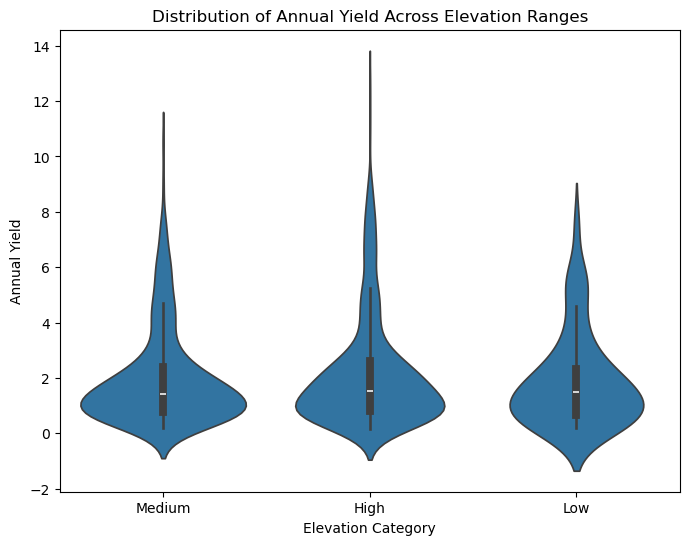

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Categorize elevation
def categorize_elevation(elevation):
    if elevation < 300:
        return "Low"
    elif 300 <= elevation <= 600:
        return "Medium"
    else:
        return "High"

df["Elevation_Category"] = df["Elevation"].apply(categorize_elevation)

# Step 2: Create violin plot
plt.figure(figsize=(8, 6))
sns.violinplot(x="Elevation_Category", y="Annual_yield", data=df)

plt.title("Distribution of Annual Yield Across Elevation Ranges")
plt.xlabel("Elevation Category")
plt.ylabel("Annual Yield")

plt.show()


In [31]:
def sum_crop_lengths(crops, index=0):
    # Base case
    if index == len(crops):
        return 0
    
    # Recursive step: add length of current crop
    return len(crops[index]) + sum_crop_lengths(crops, index + 1)

# Get unique crop types
unique_crops = df["Crop_type"].unique()

# Calculate the sum
total_sum = sum_crop_lengths(unique_crops)

print(total_sum)

42


In [32]:
from scipy import stats

# Assuming your data is in a DataFrame called df
# with columns: 'Crop_type' and 'Annual_yield'

# Separate the two groups
coffee_yield = df[df['Crop_type'] == 'coffee']['Annual_yield']
banana_yield = df[df['Crop_type'] == 'banana']['Annual_yield']

# Perform independent t-test (Welch’s t-test by default)
t_stat, p_value = stats.ttest_ind(coffee_yield, banana_yield, equal_var=False)

print("p-value:", round(p_value, 3))

p-value: 0.598
